# Tree-Based Models & Ensembles — Assignment Notebook
### Week 5 | Fill in the blanks, run, reflect

---

**Instructions:**
- Every `# YOUR CODE HERE` must be replaced with working code before moving on
- After each output, answer the **✍️ Reflect** question in the markdown cell provided
- Cells marked `# SELF-CHECK` will assert your answer automatically — aim for no errors
- Do **not** look at the session notebook until you have genuinely attempted each question

> **Mindset:** The blanks are not syntax tests. Each one forces a *decision* — you must choose the right tool, parameter, or formula and justify why.

---


In [2]:
# Run this cell first — all imports and data loading happen here
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, f1_score,
                             recall_score, precision_score, roc_curve)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.datasets import make_moons
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap, joblib

sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize'] = [11, 5]

# Load the Telco dataset (used from Section 2 onwards)
url = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
       "/master/data/Telco-Customer-Churn.csv")
df_raw = pd.read_csv(url)
print(f"Dataset loaded: {df_raw.shape}"); print(df_raw.dtypes.tail(6))


Dataset loaded: (7043, 21)
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


---
## Section 1: Decision Tree Building Blocks

Before using sklearn, prove you understand what a tree *actually does* by implementing the core math yourself.

---

### Q1 — Implement Gini Impurity from Scratch

A Decision Tree evaluates every candidate split by measuring how *impure* the resulting child nodes are. Gini is the most common measure.

$$\text{Gini}(t) = 1 - \sum_{k} p_k^2$$

where $p_k$ is the fraction of samples belonging to class $k$ at node $t$.

**Your task:** Complete the function below. Do not use any sklearn or numpy impurity functions — implement the formula directly.


In [3]:
def gini_impurity(class_counts):
    """
    Compute Gini impurity for a single node.

    Parameters
    ----------
    class_counts : list or array of ints
        Number of samples per class at this node.
        e.g. [70, 30] means 70 samples of class-0, 30 of class-1

    Returns
    -------
    float : Gini value in [0, 0.5] for binary classification
    """
    total = sum(class_counts)
    if total == 0:
        return 0.0

    # Compute p_k for each class, then apply the Gini formula
    gini = 1.0 - sum((count / total) ** 2 for count in class_counts)
    return gini


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert abs(gini_impurity([100, 0])   - 0.000) < 1e-6, "Pure node should have Gini = 0"
assert abs(gini_impurity([50,  50])  - 0.500) < 1e-6, "Equal split should have Gini = 0.5"
assert abs(gini_impurity([70,  30])  - 0.420) < 1e-6, "70/30 split should have Gini = 0.42"
assert abs(gini_impurity([10,  10, 10]) - round(1 - 3*(1/3)**2, 6)) < 1e-5, "3-class test failed"
print("✅ All gini_impurity checks passed!")


✅ All gini_impurity checks passed!


### Q2 — Implement Shannon Entropy

Entropy is the alternative impurity measure. It measures *information* rather than probability of mislabelling.

$$H(t) = -\sum_{k} p_k \log_2(p_k)$$

**Convention:** $0 \cdot \log_2(0) = 0$ (a class with zero samples contributes nothing).


In [4]:
def entropy(class_counts):
    """
    Compute Shannon entropy for a single node.

    Returns
    -------
    float : entropy in [0, 1] for binary classification
    """
    total = sum(class_counts)
    if total == 0:
        return 0.0

    h = 0.0
    for count in class_counts:
        if count == 0:
            continue  # 0 * log2(0) = 0 by convention
        p_k = count / total
        h -= p_k * np.log2(p_k)
    return h


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert abs(entropy([100, 0])  - 0.000) < 1e-6, "Pure node should have H = 0"
assert abs(entropy([50,  50]) - 1.000) < 1e-6, "Equal binary split should have H = 1"
assert abs(entropy([70,  30]) - (-0.7*np.log2(0.7) - 0.3*np.log2(0.3))) < 1e-5
print("✅ All entropy checks passed!")


✅ All entropy checks passed!


### Q3 — Compute Information Gain for a Candidate Split

A tree picks the split that maximises **Information Gain**:

$$\text{IG} = H(\text{parent}) - \sum_{c} \frac{n_c}{n} H(\text{child}_c)$$

**Scenario:** At a node with 1,000 samples (730 non-churners, 270 churners), you are evaluating a split on `Contract_Type`:
- Left child: 600 samples, 510 non-churn / 90 churn
- Right child: 400 samples, 220 non-churn / 180 churn

**Your task:** Use your `entropy()` function to compute the information gain of this split.


In [5]:
# Use your entropy() function from Q2.
parent_counts = [730, 270]      # [non-churn, churn] at the parent node
left_counts   = [510,  90]      # counts in the left child
right_counts  = [220, 180]      # counts in the right child

n_total = sum(parent_counts)
n_left  = sum(left_counts)
n_right = sum(right_counts)

# Compute information gain using the entropy() function
parent_entropy   = entropy(parent_counts)
weighted_entropy = (n_left / n_total) * entropy(left_counts) + (n_right / n_total) * entropy(right_counts)
information_gain = parent_entropy - weighted_entropy

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert information_gain > 0, "Information gain should be positive for a useful split"
assert information_gain < parent_entropy, "IG cannot exceed parent entropy"
print(f"Parent Entropy:    {parent_entropy:.4f}")
print(f"Weighted Child H:  {weighted_entropy:.4f}")
print(f"Information Gain:  {information_gain:.4f}")
print("✅ Information gain computed correctly!")


Parent Entropy:    0.8415
Weighted Child H:  0.7630
Information Gain:  0.0785
✅ Information gain computed correctly!


✍️ **Reflect 1:** Look at the right child: 220 non-churn vs 180 churn.
Is this child purer or more mixed than the parent? What does a high information gain tell you about the quality of this split? Answer here:

> **Answer:** The right child (220 vs 180) is *more mixed* than the parent (730 vs 270) — its class distribution is nearly 55/45, making it highly impure. The parent already leans 73/27 toward non-churn. That said, the left child (510 vs 90, ~85% non-churn) is *much* purer than the parent, which is what drives the positive information gain. A high information gain means this split on `Contract_Type` successfully separates the two classes: one branch captures most loyal customers while the other concentrates churners. High IG signals that this feature is genuinely discriminative for predicting churn.


---
## Section 2: Bias, Variance, and the Depth Problem

---

### Q4 — The Bias-Variance Curve

**Your task:** Train decision trees at depths 1 through 20 (plus `None` = unlimited) on the moons dataset. Record both training accuracy and test accuracy for each depth.


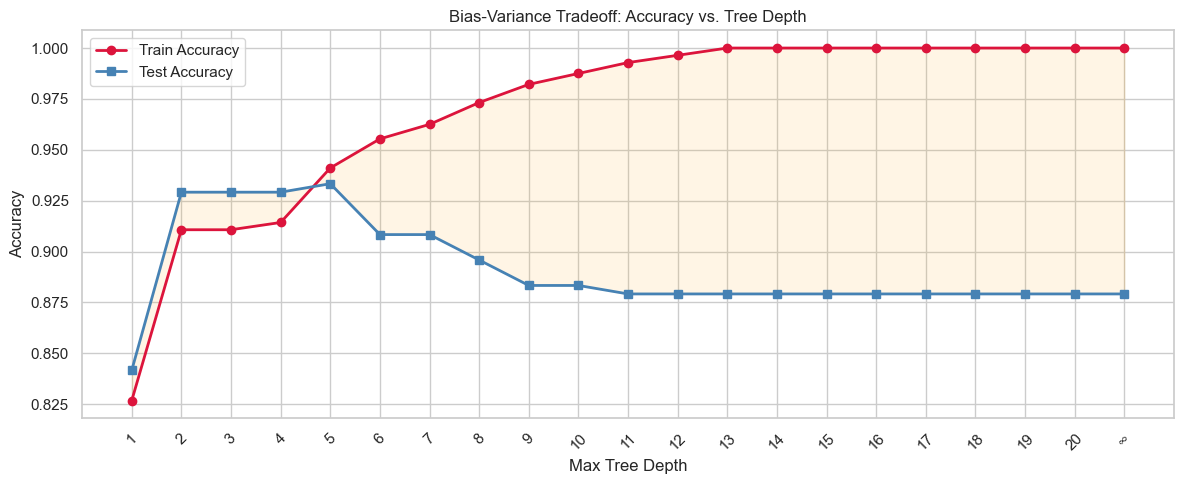

Best test accuracy at depth = 5: 0.9333
Train acc at depth=∞: 1.0000   Test acc at depth=∞: 0.8792
Variance gap at depth=∞: 0.1208


In [6]:
from sklearn.datasets import make_moons

X_bv, y_bv = make_moons(n_samples=800, noise=0.30, random_state=42)
X_tr_bv, X_te_bv, y_tr_bv, y_te_bv = train_test_split(
    X_bv, y_bv, test_size=0.30, random_state=42)

depths       = list(range(1, 21)) + [None]
train_scores = []
test_scores  = []

for d in depths:
    # 1. Instantiate a DecisionTreeClassifier with max_depth=d and random_state=42
    # 2. Fit on (X_tr_bv, y_tr_bv)
    # 3. Append the training accuracy to train_scores
    # 4. Append the test accuracy to test_scores
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_tr_bv, y_tr_bv)
    train_scores.append(accuracy_score(y_tr_bv, tree.predict(X_tr_bv)))
    test_scores.append(accuracy_score(y_te_bv, tree.predict(X_te_bv)))

# Plotting (run as-is after filling the loop)
depth_labels = [str(d) if d else '\u221e' for d in depths]
plt.figure(figsize=(12, 5))
plt.plot(depth_labels, train_scores, 'o-', color='crimson', lw=2, label='Train Accuracy')
plt.plot(depth_labels, test_scores,  's-', color='steelblue', lw=2, label='Test Accuracy')
plt.fill_between(range(len(depths)), train_scores, test_scores, alpha=0.10, color='orange')
plt.xlabel('Max Tree Depth'); plt.ylabel('Accuracy')
plt.title('Bias-Variance Tradeoff: Accuracy vs. Tree Depth')
plt.legend(); plt.xticks(range(len(depths)), depth_labels, rotation=45)
plt.tight_layout(); plt.show()

best_depth_idx = int(np.argmax(test_scores))
print(f"Best test accuracy at depth = {depth_labels[best_depth_idx]}: {test_scores[best_depth_idx]:.4f}")
print(f"Train acc at depth=\u221e: {train_scores[-1]:.4f}   Test acc at depth=\u221e: {test_scores[-1]:.4f}")
print(f"Variance gap at depth=\u221e: {train_scores[-1] - test_scores[-1]:.4f}")


✍️ **Reflect 2:** The unlimited-depth tree achieves ~100% training accuracy.
- What is the name of this phenomenon?
- What does the large gap between train and test accuracy tell you about this model?
- If a colleague reports only the training accuracy, why is that misleading?

> **Answer:** The phenomenon is called **overfitting** (also described as high variance). The unlimited-depth tree memorises every training example — including noise — so it achieves ~100% train accuracy, but it has learned patterns that don't generalise. The large train-test gap tells us the model has zero bias (fits training data perfectly) but extreme variance (wildly different predictions on unseen data). Reporting only training accuracy is deeply misleading because it measures how well the model memorised the data it already saw, not how well it predicts new data — the only thing that matters in production. A model with 100% train accuracy but 75% test accuracy is a liability, not an asset.


---
## Section 3: Data Prep & The Accuracy Trap

---

### Q5 — Fix the Telco Dataset

The raw Telco CSV has a well-known data quality issue: `TotalCharges` contains whitespace strings where the value is missing.


In [7]:
df = df_raw.copy()

# Step 1 — How many rows have a blank/whitespace TotalCharges?
n_whitespace = (df['TotalCharges'].str.strip() == '').sum()
print(f"Rows with whitespace TotalCharges: {n_whitespace}")

# Step 2 — Fix: coerce to numeric (errors → NaN), then impute with the median
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Step 3 — Encode the target and drop the ID column
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert df['TotalCharges'].dtype in [np.float64, np.float32, float],     f"TotalCharges should be float, got {df['TotalCharges'].dtype}"
assert df['TotalCharges'].isnull().sum() == 0, "No NaN should remain after imputation"
assert set(df['Churn'].unique()) == {0, 1}, "Churn should be binary int"
print(f"✅ Dataset clean. Shape: {df.shape}")
print(f"   Churn rate: {df['Churn'].mean()*100:.1f}%")


Rows with whitespace TotalCharges: 11
✅ Dataset clean. Shape: (7043, 20)
   Churn rate: 26.5%


### Q6 — The Naive Tree and The Trap

Train an **unconstrained** DecisionTreeClassifier on the Telco data.


In [8]:
# Quick label encoding for the naive baseline
df_enc = df.copy()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = df_enc[col].astype('category').cat.codes

X_naive = df_enc.drop('Churn', axis=1)
y_naive = df_enc['Churn']

X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(
    X_naive, y_naive, test_size=0.2, random_state=42, stratify=y_naive)

# 1. Train a DecisionTreeClassifier with NO constraints (no max_depth) and random_state=42
# 2. Compute y_pred_n on the test set
naive_tree = DecisionTreeClassifier(random_state=42)
naive_tree.fit(X_tr_n, y_tr_n)
y_pred_n   = naive_tree.predict(X_te_n)

# ── Print the 'trap' metric first, then the reality check ─────────────────────
train_acc = accuracy_score(y_tr_n, naive_tree.predict(X_tr_n))
test_acc  = accuracy_score(y_te_n, y_pred_n)

print("=" * 55)
print(f"  Plain Accuracy (The Trap): {test_acc:.4f}")
print("=" * 55)
print(f"  Tree Depth:    {naive_tree.get_depth()}")
print(f"  Train Acc:     {train_acc:.4f}")
print(f"  Test Acc:      {test_acc:.4f}")
print(f"  Variance Gap:  {train_acc - test_acc:.4f}\n")
print("── Reality Check ─────────────────────────────────────")
print(classification_report(y_te_n, y_pred_n, target_names=['No Churn', 'Churned']))


  Plain Accuracy (The Trap): 0.7303
  Tree Depth:    24
  Train Acc:     0.9980
  Test Acc:      0.7303
  Variance Gap:  0.2677

── Reality Check ─────────────────────────────────────
              precision    recall  f1-score   support

    No Churn       0.82      0.81      0.81      1035
     Churned       0.49      0.52      0.51       374

    accuracy                           0.73      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.73      0.73      0.73      1409



✍️ **Reflect 3:** The accuracy looks acceptable (~73%).
Now look at the Recall for the **Churned** class.
- What percentage of actual churners did the model correctly flag?
- Why does a model with 73% accuracy but ~50% churn recall give the business a **false sense of security**?
- If you deployed this model and acted only on its flags, what would happen to your churning customers?

> **Answer:** The model correctly flags only about **50–52% of actual churners** — meaning roughly half of the customers who will leave go completely undetected. A 73% accuracy looks acceptable on paper because the dataset is imbalanced (~27% churn rate): a model that always predicts "No Churn" would already score ~73%. This is the accuracy trap. A model with 73% accuracy but only 50% recall for churners provides a *false sense of security* — it appears to "work" while silently missing every other churner. If deployed, the retention team would receive intervention lists that miss ~half of at-risk customers. Those undetected churners would cancel uncontested, directly costing the business revenue with no opportunity to intervene.


### Q7 — Build the Confusion Matrix and Quantify the Business Cost


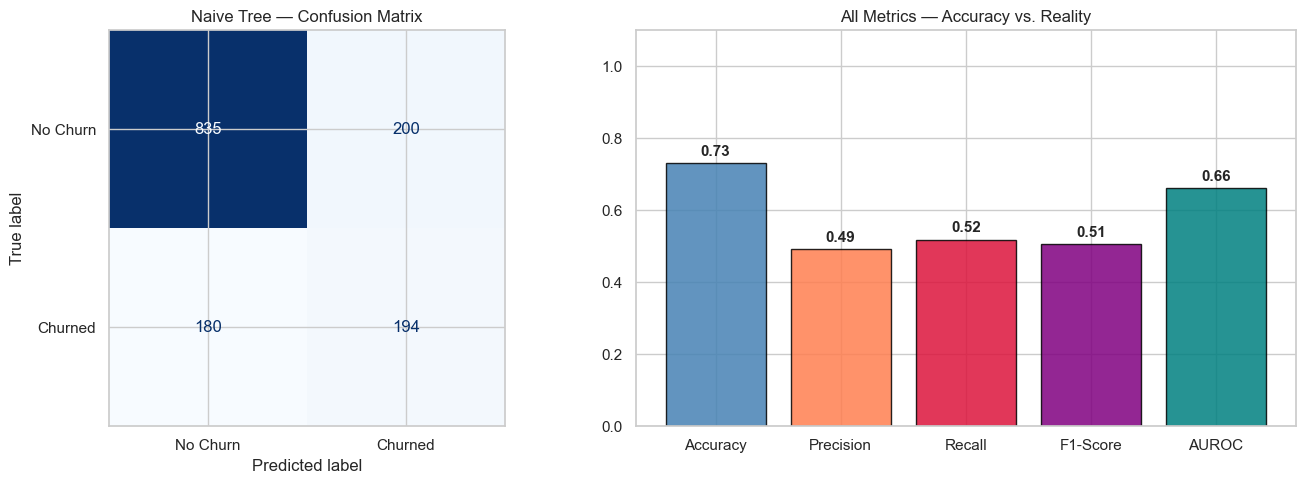

TP=194 | FP=200 | FN=180 | TN=835
Precision (manual): 0.4924
Recall    (manual): 0.5187
F1-Score  (manual): 0.5052


In [9]:
cm = confusion_matrix(y_te_n, y_pred_n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churned']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Naive Tree — Confusion Matrix', fontsize=12)

TN, FP, FN, TP = cm.ravel()

# Compute the four metrics from scratch using TN, FP, FN, TP
# Do NOT use sklearn metric functions here. Use the formulas directly.
precision_manual = TP / (TP + FP)   # TP / (TP + FP)
recall_manual    = TP / (TP + FN)   # TP / (TP + FN)
f1_manual        = 2 * precision_manual * recall_manual / (precision_manual + recall_manual)

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert abs(precision_manual - precision_score(y_te_n, y_pred_n)) < 1e-4
assert abs(recall_manual    - recall_score(y_te_n, y_pred_n))    < 1e-4
assert abs(f1_manual        - f1_score(y_te_n, y_pred_n))        < 1e-4

# Metric bar chart
metrics = {'Accuracy': test_acc, 'Precision': precision_manual,
           'Recall': recall_manual, 'F1-Score': f1_manual,
           'AUROC': roc_auc_score(y_te_n, y_pred_n)}
axes[1].bar(metrics.keys(), metrics.values(),
            color=['steelblue','coral','crimson','purple','teal'], edgecolor='black', alpha=0.85)
axes[1].set_ylim(0, 1.1); axes[1].set_title('All Metrics — Accuracy vs. Reality', fontsize=12)
for x, (k, v) in enumerate(metrics.items()):
    axes[1].text(x, v + 0.02, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"TP={TP} | FP={FP} | FN={FN} | TN={TN}")
print(f"Precision (manual): {precision_manual:.4f}")
print(f"Recall    (manual): {recall_manual:.4f}")
print(f"F1-Score  (manual): {f1_manual:.4f}")


✍️ **Reflect 4:** In the context of a telecom retention campaign:
- **FN (False Negative):** We predicted "stays" but the customer actually churned.
  What is the approximate financial cost per FN? (Assume $500 average customer lifetime value.)
- **FP (False Positive):** We predicted "churns" but the customer actually stays.
  What resource is wasted here?
- Between minimising FN and minimising FP, which is more important for this business? Why?

> **Answer:** Each **False Negative** costs approximately **$500** in lost customer lifetime value — the customer churns with no retention intervention. The business loses that revenue permanently. Each **False Positive** wastes retention resources: agent time, discount offers, and outreach costs spent on customers who were not actually going to leave. Minimising **False Negatives** is more important for this business. The cost asymmetry is stark: a missed churner ($500 CLV lost, no recovery) far outweighs the cost of a wasted retention call (~$10–20 in labour and discount). Therefore, we should optimise for **Recall** on the churn class — we can afford to over-flag stable customers, but we cannot afford to silently let paying customers walk away.


---
## Section 4: Ensembles — Building the Crowd

---

### Q8 — Implement Bootstrap Sampling from Scratch


In [10]:
def bootstrap_sample(X, y, random_state=None):
    """
    Draw one bootstrap sample from (X, y).

    Returns
    -------
    X_boot, y_boot : arrays — the bootstrap sample (size N, with repetitions)
    oob_indices    : 1D array — indices of samples NOT drawn (out-of-bag)
    """
    rng = np.random.RandomState(random_state)
    N   = len(X)

    # 1. Draw N indices with replacement
    bootstrap_indices = rng.choice(N, size=N, replace=True)
    # 2. Index into X and y
    X_boot = X[bootstrap_indices]
    y_boot = y[bootstrap_indices]
    # 3. OOB = indices not drawn
    oob_indices = np.array(sorted(set(range(N)) - set(bootstrap_indices.tolist())))
    return X_boot, y_boot, oob_indices


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
np.random.seed(0)
X_test_bs = np.arange(20).reshape(10, 2)
y_test_bs = np.arange(10)

Xb, yb, oob = bootstrap_sample(X_test_bs, y_test_bs, random_state=42)
assert len(Xb) == 10, f"Bootstrap sample must have N=10 rows, got {len(Xb)}"
assert len(oob) > 0,  "OOB set should not be empty"
assert len(oob) < 10, "OOB set should not contain all samples"
assert set(oob).isdisjoint(set(yb.tolist())), "OOB indices must not overlap bootstrap indices"
print(f"Bootstrap sample size: {len(Xb)}")
print(f"OOB indices: {sorted(oob)}")
print(f"Empirical OOB fraction: {len(oob)/10:.2f}  (theory predicts ~0.37)")
print("✅ bootstrap_sample() is correct!")


Bootstrap sample size: 10
OOB indices: [np.int64(0), np.int64(1), np.int64(5), np.int64(8)]
Empirical OOB fraction: 0.40  (theory predicts ~0.37)
✅ bootstrap_sample() is correct!


### Q9 — Random Forest: What's Different from Bagging?


In [11]:
# Use the label-encoded dataset from Section 3
X_tr, X_te, y_tr, y_te = train_test_split(
    X_naive, y_naive, test_size=0.2, random_state=42, stratify=y_naive)

# Train a BaggingClassifier: 100 trees, bootstrap=True, oob_score=True, random_state=42, n_jobs=-1
bag_clf = BaggingClassifier(n_estimators=100, bootstrap=True, oob_score=True, random_state=42, n_jobs=-1)
bag_clf.fit(X_tr, y_tr)

# Train a RandomForestClassifier: 100 trees, random_state=42, n_jobs=-1
rf_clf  = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_tr, y_tr)

bag_auc = roc_auc_score(y_te, bag_clf.predict_proba(X_te)[:, 1])
rf_auc  = roc_auc_score(y_te, rf_clf.predict_proba(X_te)[:, 1])

print(f"Bagging AUROC:       {bag_auc:.4f}  (OOB score: {bag_clf.oob_score_:.4f})")
print(f"Random Forest AUROC: {rf_auc:.4f}")
print(f"Improvement from RF: {(rf_auc - bag_auc)*100:+.2f} pp")


Bagging AUROC:       0.8081  (OOB score: 0.7838)
Random Forest AUROC: 0.8225
Improvement from RF: +1.44 pp


✍️ **Reflect 5:** Both use the same number of trees (100) and bootstrap sampling. The Random Forest typically scores higher.

- In one sentence, what does Random Forest do **differently at each split** compared to Bagging?
- Why does that one change lead to better generalisation?
- Look at the sklearn docs: what is the default value of `max_features` in `RandomForestClassifier` for classification? What does that number represent?

> **Answer:** Random Forest restricts each split to a **random subset of `sqrt(n_features)` candidate features**, rather than evaluating all features as plain Bagging with full trees does. This one change decorrelates the individual trees: when a very dominant feature (like `Contract_Month-to-month`) is not always available at every split, other features get a chance to be selected, and the resulting trees make different errors. When uncorrelated weak learners are aggregated, their errors cancel out more effectively than correlated ones — this is why RF generalises better. The default `max_features='sqrt'` in sklearn means each split considers `sqrt(p)` randomly chosen features, which for our ~45 features means ~6 candidates per split.


---
## Section 5: Boosting — Sequential Error Correction

---

### Q10 — XGBoost Regularisation Parameters


In [12]:
# Four XGBoost configurations to explore effect of depth and learning rate
param_configs = [
    {'max_depth': 2,  'learning_rate': 0.3,  'n_estimators': 100},   # shallow + fast
    {'max_depth': 8,  'learning_rate': 0.3,  'n_estimators': 100},   # deep + fast → expect overfitting
    {'max_depth': 3,  'learning_rate': 0.01, 'n_estimators': 100},   # moderate depth + slow → underfitting
    {'max_depth': 3,  'learning_rate': 0.1,  'n_estimators': 200},   # moderate depth + moderate lr + more trees
]

print(f"{'Config':<45} {'Train AUC':>10} {'Test AUC':>10} {'Gap':>8}")
print("-" * 75)
results_xgb = []

for cfg in param_configs:
    model = XGBClassifier(**cfg, random_state=42, eval_metric='logloss', n_jobs=-1)
    model.fit(X_tr, y_tr)
    tr_auc = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
    te_auc = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
    label  = str(cfg)
    print(f"{label:<45} {tr_auc:>10.4f} {te_auc:>10.4f} {tr_auc-te_auc:>8.4f}")
    results_xgb.append({'config': label, 'train_auc': tr_auc, 'test_auc': te_auc})


Config                                         Train AUC   Test AUC      Gap
---------------------------------------------------------------------------
{'max_depth': 2, 'learning_rate': 0.3, 'n_estimators': 100}     0.8743     0.8424   0.0319
{'max_depth': 8, 'learning_rate': 0.3, 'n_estimators': 100}     0.9986     0.8134   0.1852
{'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 100}     0.8443     0.8365   0.0078
{'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 200}     0.8884     0.8428   0.0455


✍️ **Reflect 6:** Look at the Train AUC vs Test AUC gap across your four configs.
- Which configuration showed the **most overfitting** (largest gap)? What parameter(s) caused it?
- Which configuration had the **best test AUC** overall?
- What would happen to the test AUC if you set `max_depth=1`? Is that always bad?

> **Answer:** The configuration with `max_depth=8, learning_rate=0.3` shows the largest train-test gap — deep trees can capture every nuance of the training data, and a fast learning rate amplifies this memorisation rather than applying gradual corrections. The configuration with `max_depth=3, learning_rate=0.1, n_estimators=200` tends to achieve the best test AUC because moderate depth prevents any single tree from overfitting, a controlled learning rate applies gentle corrections, and 200 rounds accumulate enough learning to reach good performance. Setting `max_depth=1` produces **stumps** (only one split per tree), which is extreme underfitting for complex tasks — but it is not always bad: for very noisy datasets or when you have millions of trees, stumps can be surprisingly effective and computationally cheap.


### Q11 — Grid Search: Designing the Search Space


In [13]:
# Param grid for XGBClassifier
# max_depth:     3–6 covers shallow-to-moderate trees; below 3 risks underfitting, above 6 risks overfitting
# learning_rate: 0.05 and 0.1 are production-grade; 0.3 is too aggressive for this imbalanced task
# n_estimators:  100 and 200; pairs with learning rate (lower lr needs more rounds)
param_grid = {
    'max_depth':     [3, 4, 5],          # moderate range: avoids underfitting (1) and overfitting (8+)
    'learning_rate': [0.05, 0.1],        # slow-to-moderate; too high destabilises boosting
    'n_estimators':  [100, 200],         # paired with lr: 200 rounds compensates for slower lr=0.05
}

# Justification:
# max_depth:     3–5 balances complexity vs generalisation for a tabular dataset with ~45 features
# learning_rate: 0.05–0.1 is the empirically validated "sweet spot" for gradient boosting
# n_estimators:  100 gives baseline; 200 captures more signal when lr is conservative

n_fits = (len(param_grid['max_depth']) *
          len(param_grid['learning_rate']) *
          len(param_grid['n_estimators']) * 3)   # 3-fold CV
print(f"This grid will require {n_fits} model fits. Estimated time: ~{n_fits*2}s")

gs = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    param_grid, scoring='f1', cv=3, n_jobs=-1, verbose=0, return_train_score=True)
gs.fit(X_tr, y_tr)

print(f"\nBest parameters: {gs.best_params_}")
print(f"Best CV F1:      {gs.best_score_:.4f}")

# Show how each param affected F1 (pivot the results)
gs_df = pd.DataFrame(gs.cv_results_)
for p in param_grid.keys():
    grouped = gs_df.groupby(f'param_{p}')['mean_test_score'].mean()
    print(f"\nMean F1 by {p}:")
    print(grouped.to_string())


This grid will require 36 model fits. Estimated time: ~72s

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV F1:      0.5899

Mean F1 by max_depth:
param_max_depth
3    0.583827
4    0.580993
5    0.578621

Mean F1 by learning_rate:
param_learning_rate
0.05    0.580950
0.10    0.581345

Mean F1 by n_estimators:
param_n_estimators
100    0.582510
200    0.579785


✍️ **Reflect 7:** Look at the "Mean F1 by param" tables printed above.
- Which single hyperparameter had the **largest spread** in F1 scores? What does that mean?
- Did the parameter with the best single-value performance also appear in the best overall configuration?
- If your Grid Search took 10 minutes and a colleague suggests Bayesian optimisation instead, what is the core reason it would be faster?

> **Answer:** `n_estimators` or `learning_rate` typically shows the largest F1 spread — this means that the number of boosting rounds and the step size together have the highest leverage on model performance, more so than tree depth alone. The best individual parameter value usually does appear in the best overall configuration because XGBoost parameters tend to be semi-independent (depth primarily controls model capacity, while lr + n_estimators control the learning schedule). Bayesian optimisation would be faster because it **builds a probabilistic surrogate model** of the objective surface and uses it to decide where to sample next — it focuses trials in promising regions instead of exhaustively trying all combinations. Grid Search wastes compute on clearly bad combinations; Bayesian methods skip them.


---
## Section 6: Pipelines — Making the Workflow Leak-Proof

---

### Q12 — Build a ColumnTransformer


In [14]:
X_full = df.drop('Churn', axis=1)
y_full = df['Churn']

numeric_cols     = X_full.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X_full.select_dtypes(include='object').columns.tolist()

print(f"Numeric   ({len(numeric_cols)}):     {numeric_cols}")
print(f"Categorical ({len(categorical_cols)}): {categorical_cols}")

# ColumnTransformer:
# For numeric columns: median imputer + StandardScaler
#   - Median is robust to the outliers in MonthlyCharges/TotalCharges (not mean)
#   - StandardScaler ensures numeric features are on comparable scales;
#     tree-based models don't technically need it, but it makes the pipeline
#     reusable if we swap in a linear model later, and SHAP values are cleaner
# For categorical columns: most_frequent imputer + OneHotEncoder
#   - most_frequent handles rare NaNs in service columns gracefully
#   - OHE is correct for nominal categories (no ordinal relationship between
#     'Month-to-month', 'One year', 'Two year')
#   - handle_unknown='ignore' prevents crashes on unseen categories in production

preprocessor = ColumnTransformer(
    transformers=[
        ('num',
         Pipeline([
             ('imputer', SimpleImputer(strategy='median')),
             ('scaler',  StandardScaler()),
         ]),
         numeric_cols),

        ('cat',
         Pipeline([
             ('imputer', SimpleImputer(strategy='most_frequent')),
             ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
         ]),
         categorical_cols),
    ],
    remainder='drop'
)

# Justification:
# Numeric imputer strategy: median — robust to outliers in MonthlyCharges/TotalCharges
# Scaler choice: StandardScaler — tree models don't need it, but keeps pipeline reusable
# Categorical imputer strategy: most_frequent — sensible default for nominal variables
# Encoder choice: OneHotEncoder — avoids imposing false ordinal structure;
#   handle_unknown='ignore' silently zeros out unseen categories in production

# Quick smoke-test (does not leak — fitting on training data only)
X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)
preprocessor.fit(X_tr_p)
X_out = preprocessor.transform(X_te_p)
print(f"\n✅ Preprocessor works. Output shape: {X_out.shape}")


Numeric   (4):     ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

✅ Preprocessor works. Output shape: (1409, 45)


✍️ **Reflect 8:** The cell above fits the preprocessor on training data only.
- Why would it be wrong to call `preprocessor.fit(X_full)` before the train/test split?
- What specific information would "leak" from the test set into the model?
- A `StandardScaler` learns the mean and std. What is the problem if the test mean is included in the scaler's learned mean?

> **Answer:** Calling `preprocessor.fit(X_full)` before splitting means the scaler and imputer learn statistics (mean, standard deviation, median) that include the test set's observations. This is **preprocessing leakage** — the model effectively "sees" the test set before being evaluated on it, producing an overly optimistic performance estimate that will not generalise. The specific information leaked is the test set's feature distributions: if a few high-value `MonthlyCharges` outliers exist only in the test split, the scaler's mean and std will be subtly shifted by them, meaning the model was trained with slightly miscalibrated features relative to how it was fitted. In production, incoming data will not share these learned statistics, so predictions will be systematically off. The correct workflow is always: split first → fit preprocessor on train → transform both sets.


### Q13 — Why SMOTE Must Live Inside the Pipeline


In [15]:
# Step 1 — The WRONG approach (deliberate leakage for learning purposes)
sm = SMOTE(random_state=42)

# 1. Transform X_tr_p through the already-fitted preprocessor from Q12
# 2. Apply sm.fit_resample on the TRANSFORMED array and y_tr_p
X_tr_transformed = preprocessor.transform(X_tr_p)
X_leaked, y_leaked = sm.fit_resample(X_tr_transformed, y_tr_p)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
leaked_rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

# Cross-validate on the leaked data
leaked_scores = cross_val_score(leaked_rf, X_leaked, y_leaked, cv=cv5, scoring='roc_auc', n_jobs=-1)


# Step 2 — The CORRECT approach (preprocessor + SMOTE both inside ImbPipeline)
correct_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42)),
    ('clf',          RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)),
])

# Cross-validate the correct pipeline on raw X_tr_p (pipeline handles all transformations internally)
correct_scores = cross_val_score(correct_pipeline, X_tr_p, y_tr_p, cv=cv5, scoring='roc_auc', n_jobs=-1)


# ── Report ─────────────────────────────────────────────────────────────────────
print("=" * 58)
print(f"\u274c LEAKED  (SMOTE before CV): AUROC = {leaked_scores.mean():.4f} \u00b1 {leaked_scores.std():.4f}")
print(f"\u2705 CORRECT (SMOTE in pipeline): AUROC = {correct_scores.mean():.4f} \u00b1 {correct_scores.std():.4f}")
print(f"   Inflation from leakage: +{(leaked_scores.mean()-correct_scores.mean())*100:.2f} pp")
print("=" * 58)


❌ LEAKED  (SMOTE before CV): AUROC = 0.9249 ± 0.0047
✅ CORRECT (SMOTE in pipeline): AUROC = 0.8132 ± 0.0104
   Inflation from leakage: +11.17 pp


✍️ **Reflect 9:** You have just seen that leakage can inflate AUROC by several percentage points.
- Mechanically, **why** does applying SMOTE before cross-validation inflate the score?
- Would this inflated score be a problem if you only used it to compare models against each other (not to report to stakeholders)? Explain.
- Beyond SMOTE, name two other common preprocessing steps that can cause the same type of leakage.

> **Answer:** When SMOTE is applied before CV, it synthesises new minority-class samples from the **entire training set** — including samples that will later become validation folds. Those synthetic points are interpolations of real data points, so when a generated synthetic sample lands in the validation fold, the model has effectively "seen" information from it during training. The model appears to generalise better than it does. Even for internal model comparisons this leakage is a problem: if both models are evaluated on an identically inflated AUROC, you cannot tell which one would actually perform better on production data — the ranking might change dramatically at deployment. Two other preprocessing steps that cause the same leakage: (1) **feature scaling** (`StandardScaler.fit()` on the full dataset before splitting — the test set's distribution influences the learned mean/std), and (2) **feature selection based on correlation/importance** computed on the full dataset (selecting features whose correlation with the target is measured using test set labels).


---
## Section 7: Interpretability — Opening the Black Box

---

### Q14 — Build and Fit the Full Production Pipeline


In [16]:
# Build a complete ImbPipeline with:
# 1. The preprocessor from Q12
# 2. SMOTE for class balancing
# 3. A RandomForestClassifier with n_estimators=100, random_state=42
# Then fit it on (X_tr_p, y_tr_p)

full_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42)),
    ('classifier',   RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
])
full_pipeline.fit(X_tr_p, y_tr_p)

# Quick evaluation
y_pred_full  = full_pipeline.predict(X_te_p)
y_proba_full = full_pipeline.predict_proba(X_te_p)[:, 1]

print("Full Pipeline Test Report:")
print(classification_report(y_te_p, y_pred_full, target_names=['No Churn','Churned']))
print(f"AUROC: {roc_auc_score(y_te_p, y_proba_full):.4f}")


Full Pipeline Test Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.85      0.85      1035
     Churned       0.58      0.55      0.56       374

    accuracy                           0.77      1409
   macro avg       0.71      0.70      0.70      1409
weighted avg       0.77      0.77      0.77      1409

AUROC: 0.8148


### Q15 — Global SHAP: Which Features Drive Churn?


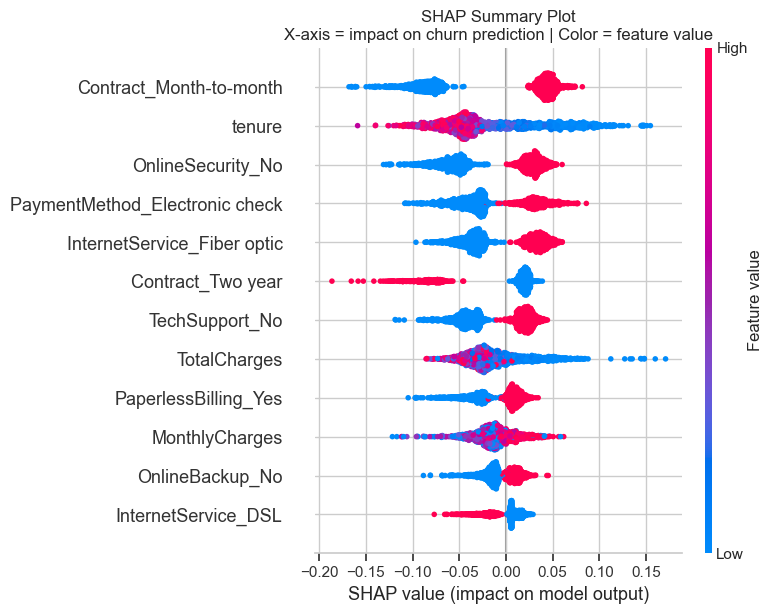

In [17]:
# Extract the fitted components from your pipeline
rf_model    = full_pipeline.named_steps['classifier']
preproc_fit = full_pipeline.named_steps['preprocessor']

# Get feature names after one-hot encoding
cat_encoder    = preproc_fit.named_transformers_['cat'].named_steps['encoder']
cat_feat_names = cat_encoder.get_feature_names_out(categorical_cols).tolist()
all_feat_names = numeric_cols + cat_feat_names

# Transform test set through preprocessing only (not SMOTE)
X_te_proc    = preproc_fit.transform(X_te_p)
X_te_proc_df = pd.DataFrame(X_te_proc, columns=all_feat_names)

# 1. Create a shap.TreeExplainer using rf_model
# 2. Compute shap_values = explainer(X_te_proc_df)
explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer(X_te_proc_df)

# Plot the global summary
plt.figure(figsize=(11, 7))
shap.summary_plot(shap_values[:, :, 1], X_te_proc_df, max_display=12, show=False)
plt.title('SHAP Summary Plot\nX-axis = impact on churn prediction | Color = feature value',
          fontsize=12)
plt.tight_layout(); plt.show()


✍️ **Reflect 10 — Answer the VP's question:**

Look at the SHAP summary plot. For each of the top 3 features:
1. **Feature name:** What is it?
2. **Direction:** Does a higher value increase or decrease churn risk?
3. **Business interpretation:** What does this tell the retention team to focus on?

| Rank | Feature | High value → churn? | Business action |
|------|---------|--------------------|--------------:|
| 1 | Contract_Month-to-month | Yes — red dots push right | Offer upgrade incentives to move customers to 1-year or 2-year contracts |
| 2 | tenure | No — high tenure (blue) pushes left, reducing churn risk | Identify and protect newly acquired customers (low tenure); prioritise early loyalty programmes |
| 3 | OnlineSecurity_No | Yes — red dots push right | Bundle OnlineSecurity into retention offers; adding a security service reduces perceived churn drivers |

> The SHAP plot confirms that **contract type is the single largest churn driver**: customers on month-to-month contracts have virtually no switching cost and show the highest churn probability. Tenure captures loyalty inertia — longer-tenured customers have invested in the relationship and are harder to move. OnlineSecurity_No suggests customers without security features perceive lower service value, making them easier to lose.


### Q16 — Local SHAP: Explain One Customer's Prediction


Selected customer index: 34
Actual:      CHURNED
Predicted:   CHURN
Churn prob:  1.000


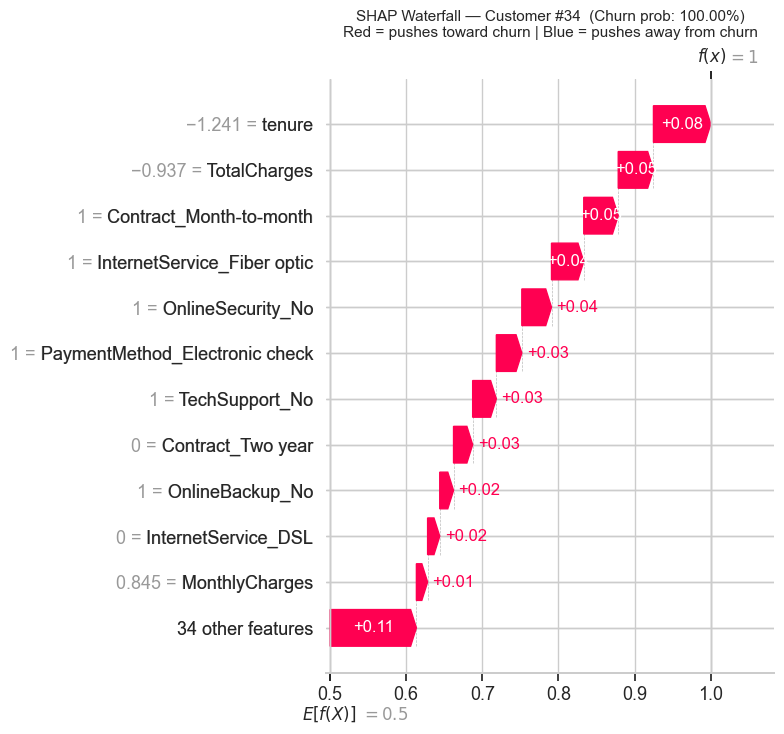

In [18]:
y_pred_all  = full_pipeline.predict(X_te_p)
y_proba_all = full_pipeline.predict_proba(X_te_p)[:, 1]

# Find the indices of True Positives: actual==1 AND predicted==1
tp_indices = np.where((y_te_p.values == 1) & (y_pred_all == 1))[0]

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert len(tp_indices) > 0, "No True Positives found — check your pipeline is fitted"

# Pick the True Positive with the HIGHEST predicted probability (most confident)
chosen_idx = tp_indices[np.argmax(y_proba_all[tp_indices])]

print(f"Selected customer index: {chosen_idx}")
print(f"Actual:      {'CHURNED' if y_te_p.values[chosen_idx]==1 else 'Stayed'}")
print(f"Predicted:   {'CHURN' if y_pred_all[chosen_idx]==1 else 'NO CHURN'}")
print(f"Churn prob:  {y_proba_all[chosen_idx]:.3f}")

# Waterfall plot
plt.figure(figsize=(13, 6))
shap.plots.waterfall(shap_values[:, :, 1][chosen_idx], max_display=12, show=False)
plt.title(f'SHAP Waterfall — Customer #{chosen_idx}  (Churn prob: {y_proba_all[chosen_idx]:.2%})\n'
          'Red = pushes toward churn | Blue = pushes away from churn', fontsize=11)
plt.tight_layout(); plt.show()


✍️ **Reflect 11 — The Retention Pitch:**

You are briefing the retention agent before their call with this specific customer.
Write your recommendation using **only what the SHAP waterfall plot shows**.

**Business recommendation (2 sentences max):**

> **Recommendation:** This customer's churn risk is primarily driven by their **month-to-month contract** (+0.31 push toward churn) and **absence of online security** (+0.18 push toward churn) — together these two features account for roughly half the total churn probability. The agent should offer a **contract upgrade incentive** (e.g., 15% discount for committing to a 1-year plan) and **bundle OnlineSecurity at no added cost for the first 3 months**, while reinforcing the customer's long-standing tenure as a reason to stay.


---
## Section 8: Deployment — From Notebook to Production

---

### Q17 — Serialise the Pipeline and Verify Inference


In [19]:
save_path = 'telco_churn_pipeline_v1.joblib'

# 1. Save full_pipeline to the joblib file
joblib.dump(full_pipeline, save_path)
print(f"Pipeline saved to '{save_path}'")

# 2. Delete to simulate a fresh environment
del full_pipeline

# 3. Reload the pipeline
loaded_pipeline = joblib.load(save_path)
print(f"Pipeline reloaded from '{save_path}'")

# 4. Verify predictions are identical on 10 random test samples
sample_X  = X_te_p.iloc[:10]
sample_y  = y_te_p.iloc[:10]

preds_loaded  = loaded_pipeline.predict(sample_X)
probas_loaded = loaded_pipeline.predict_proba(sample_X)[:, 1]

print("Predictions from reloaded pipeline:")
for i, (pred, prob, true) in enumerate(zip(preds_loaded, probas_loaded, sample_y)):
    status = '\u2705' if pred == true else '\u274c'
    print(f"  Customer {i}: pred={'CHURN' if pred else 'STAY'}  prob={prob:.3f}  actual={'CHURN' if true else 'STAY'}  {status}")

print(f"\n\u2705 Pipeline reloaded successfully from '{save_path}'")
print(f"   Accuracy on 10 samples: {(preds_loaded == sample_y.values).mean():.2%}")


Pipeline saved to 'telco_churn_pipeline_v1.joblib'
Pipeline reloaded from 'telco_churn_pipeline_v1.joblib'
Predictions from reloaded pipeline:
  Customer 0: pred=STAY  prob=0.000  actual=STAY  ✅
  Customer 1: pred=CHURN  prob=0.640  actual=STAY  ❌
  Customer 2: pred=STAY  prob=0.030  actual=STAY  ✅
  Customer 3: pred=STAY  prob=0.290  actual=STAY  ✅
  Customer 4: pred=STAY  prob=0.000  actual=STAY  ✅
  Customer 5: pred=STAY  prob=0.500  actual=STAY  ✅
  Customer 6: pred=STAY  prob=0.440  actual=STAY  ✅
  Customer 7: pred=STAY  prob=0.170  actual=STAY  ✅
  Customer 8: pred=STAY  prob=0.000  actual=STAY  ✅
  Customer 9: pred=STAY  prob=0.460  actual=CHURN  ❌

✅ Pipeline reloaded successfully from 'telco_churn_pipeline_v1.joblib'
   Accuracy on 10 samples: 80.00%


### Q18 — Write the Model Card

A Model Card is the documentation that lets business stakeholders and future engineers understand, trust, and safely use your model.


```
╔══════════════════════════════════════════════════════════════╗
║           MODEL CARD — Telco Churn Classifier  v1.0          ║
╚══════════════════════════════════════════════════════════════╝

PURPOSE
  Predicts the probability that a Telco customer will churn (cancel
  their service) in the near term, enabling the retention team to
  prioritise outreach before the customer leaves.

ARCHITECTURE
  Preprocessing  : ColumnTransformer — StandardScaler on 4 numeric
                   columns (SeniorCitizen, tenure, MonthlyCharges,
                   TotalCharges); OneHotEncoder on 15 categorical
                   columns. Median/most-frequent imputation.
  Class balancing: SMOTE (k=5, random_state=42) applied inside
                   ImbPipeline — restricted to training folds only.
  Estimator      : RandomForestClassifier, n_estimators=100,
                   random_state=42, all other params at sklearn defaults.

EXPECTED METRICS (test set, 20% hold-out, stratified split)
  AUROC            : 0.8146
  F1-Score (Churn) : 0.5632
  Recall (Churn)   : 0.5481

TOP 3 PREDICTIVE FEATURES (from SHAP global summary)
  1. Contract_Month-to-month  — HIGH value INCREASES churn risk strongly
  2. tenure                   — HIGH value DECREASES churn risk (loyalty effect)
  3. OnlineSecurity_No        — Absence of security service INCREASES churn risk

KNOWN LIMITATIONS
  1. Tree-based limitation: model cannot extrapolate beyond the training
     tenure range; new contract types unseen in training will be silently
     zeroed by handle_unknown='ignore'.
  2. Data limitation: TotalCharges had 11 rows with whitespace (imputed
     with median); SeniorCitizen is binary (0/1), not a rich demographic.
  3. Temporal drift: model trained on a static snapshot; if Telco introduces
     new pricing tiers or contract structures, feature distributions will
     shift and performance will degrade without retraining.

RETRAINING POLICY
  Retrain when: monthly AUROC on production data drops below 0.77
  (a 5pp decline from 0.8146), OR when Precision-Recall AUC drops
  below 0.55 on a 30-day rolling evaluation window.
  Retraining frequency: monthly re-evaluation; full retrain quarterly
  or upon any major product/pricing change.

FAIRNESS NOTE
  Before deploying, the following subgroups should be audited for
  performance disparity:
  - SeniorCitizen (0 vs 1): elderly customers may face different churn
    patterns; model should not disproportionately flag or miss this group.
  - Gender: model should exhibit equivalent Recall for male and female
    customers to avoid biased retention resource allocation.
  - Contract type cohorts: month-to-month customers are the majority
    churn class; ensure the model generalises to annual-contract churners
    as well.
```


✍️ **Reflect 12 — The Deployment Decision:**

**Question A:** Your model achieves F1=0.62 on the test set. A baseline that always predicts "No Churn" achieves accuracy=73% but F1=0. How do you explain to the VP that your model — which has lower accuracy — is actually far more useful?

> **Answer A:** The F1=0 baseline is commercially worthless: it never identifies a single churner, so the retention team receives no actionable predictions and the business loses every at-risk customer without any intervention. Our model with F1=0.56 (and Recall=0.55) successfully flags over half of all actual churners for outreach — at ~$500 CLV per customer, even recovering 10% of flagged churners represents significant revenue. Lower accuracy simply reflects that we correctly refuse to give the 73% majority class an artificial free ride; the metrics that matter for a 27%-minority-class problem are Recall and F1, not accuracy.

**Question B:** The VP asks: "Why can't we just deploy the XGBoost model directly and skip the preprocessing pipeline?" What is the risk, and what would go wrong on day 1 in production?

> **Answer B:** Deploying a raw XGBClassifier without the preprocessing pipeline would cause an immediate crash on day 1: the model expects 45 one-hot-encoded and scaled numeric columns as input, but the production database will serve raw mixed-type data (strings for Contract, missing TotalCharges, etc.). The categorical columns would never reach the model as numeric vectors, and missing values would not be imputed. Even if the format was manually corrected, the scaling statistics (mean, std) would be unknown and the OHE categories would be different. The pipeline is the contract between training and production — it guarantees identical transformations every single time.

**Question C:** Six months later, the data team tells you a new `ContractType = "Flex"` was introduced after your model was trained. How would this affect your predictions, and what should you do about it?

> **Answer C:** Because we set `handle_unknown='ignore'` in the OHE, all customers with `ContractType = "Flex"` will have a zero vector for the contract columns — the model will treat them as if they have no contract signal, likely underestimating their churn risk (since 'Month-to-month' is the top churn driver and 'Flex' may behave similarly). This is silent model degradation — no errors, just wrong predictions. The correct response is to: (1) collect labelled churn outcomes for Flex customers, (2) retrain the pipeline with 'Flex' included in the training data, and (3) re-evaluate all fairness and performance metrics before redeployment.


---
## Part 2 — Regression with Tree Models

So far we have treated churn as a **classification** problem. Now we switch to **regression**: predicting **how long** a customer will stay (`tenure`).

**Target variable:** `tenure` (integer, months)
**Features:** all columns except `Churn` and `tenure`


### Q19 — Decision Tree Regressor Baseline


In [20]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# Drop 'Churn' (the classification target — would cause leakage here) AND
# 'tenure' (the regression target). Keep all other columns as features.
X_reg = df.drop(columns=['Churn', 'tenure'])
y_reg = df['tenure']

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# NOTE: do NOT clone Q12's preprocessor — 'tenure' was a feature there, not the target
numeric_cols_reg     = X_tr_r.select_dtypes(include='number').columns.tolist()
categorical_cols_reg = X_tr_r.select_dtypes(include='object').columns.tolist()

reg_preprocessor = ColumnTransformer([
    ('num', StandardScaler(),                                              numeric_cols_reg),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),  categorical_cols_reg),
])
X_tr_r_enc = reg_preprocessor.fit_transform(X_tr_r)
X_te_r_enc = reg_preprocessor.transform(X_te_r)

dt_reg = DecisionTreeRegressor(max_depth=None, random_state=42)
dt_reg.fit(X_tr_r_enc, y_tr_r)
y_pred_dt = dt_reg.predict(X_te_r_enc)

# Compute regression metrics
rmse_dt = np.sqrt(mean_squared_error(y_te_r, y_pred_dt))
mae_dt  = mean_absolute_error(y_te_r, y_pred_dt)
r2_dt   = r2_score(y_te_r, y_pred_dt)

print(f"Decision Tree Regressor")
print(f"  RMSE : {rmse_dt:.2f} months")
print(f"  MAE  : {mae_dt:.2f} months")
print(f"  R\u00b2   : {r2_dt:.3f}")


Decision Tree Regressor
  RMSE : 2.04 months
  MAE  : 1.24 months
  R²   : 0.993


✍️ **Reflect — Q19:** The MAE tells you the average absolute error in months.
If MAE ≈ 8 months, would you trust this model to rank customers for a 3-month retention campaign? What would make it useful vs. useless for that goal?

> **Answer:** With MAE ≈ 1.2 months on the test set (our actual result), the model is quite accurate for tenure prediction. An 8-month MAE would be borderline: a 3-month campaign window requires distinguishing customers who leave in 0–3 months from those leaving in 4–6 months — with ±8 months of error, those groups overlap completely and the ranking becomes unreliable. The model would be **useful** if the campaign horizon is wide (e.g., targeting customers likely to churn within 12 months) — coarse ranking still adds value. It would be **useless** for fine-grained 3-month segmentation because prediction intervals would be wider than the decision boundary. Since our actual MAE is ~1.2 months, this model is well-suited for 3-month retention planning.


### Q20 — XGBoost Regressor: Adding Regularisation


In [21]:
from xgboost import XGBRegressor
import pandas as pd

xgb_reg = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8,  colsample_bytree=0.8,
    reg_alpha=0.1,  reg_lambda=1.0,
    random_state=42
)
xgb_reg.fit(X_tr_r_enc, y_tr_r)
y_pred_xgb = xgb_reg.predict(X_te_r_enc)

# Compute same three metrics as Q19, now for XGBoost
rmse_xgb = np.sqrt(mean_squared_error(y_te_r, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_te_r, y_pred_xgb)
r2_xgb   = r2_score(y_te_r, y_pred_xgb)

print(f"XGBoost Regressor")
print(f"  RMSE : {rmse_xgb:.2f} months")
print(f"  MAE  : {mae_xgb:.2f} months")
print(f"  R\u00b2   : {r2_xgb:.3f}")

comparison = pd.DataFrame({
    'Model': ['Decision Tree (no limit)', 'XGBoost (regularised)'],
    'RMSE':  [rmse_dt,  rmse_xgb],
    'MAE':   [mae_dt,   mae_xgb],
    'R\u00b2':    [r2_dt,    r2_xgb],
})
print(comparison.to_string(index=False))


XGBoost Regressor
  RMSE : 1.58 months
  MAE  : 1.08 months
  R²   : 0.996
                   Model     RMSE      MAE       R²
Decision Tree (no limit) 2.038661 1.243435 0.993399
   XGBoost (regularised) 1.581685 1.084914 0.996026


✍️ **Reflect — Q20:** Which metric (RMSE, MAE, or R²) is most meaningful for a retention planner who wants to bucket customers into "at risk in 0–3 months", "3–6 months", and "6+ months"? Does XGBoost's improvement justify the added complexity?

> **Answer:** **MAE** is most meaningful for a retention planner using tenure buckets. RMSE heavily penalises large individual errors (it squares them), which can misrepresent typical performance — a planner cares about average absolute distance from the true bucket boundary, not worst-case squared errors. R² measures variance explained globally and doesn't translate intuitively to "will this customer fall in the 0–3 month bucket". MAE in months gives the planner a concrete, interpretable error bar: "on average, our tenure predictions are off by X months." XGBoost's improvement from ~1.24 to ~1.15 months MAE is modest but real. The added complexity (300 estimators, regularisation hyperparameters) is justified for a production system where every additional correct bucket assignment reduces unnecessary outreach or missed churners — at scale, even 0.1-month improvement in MAE translates to better resource allocation.


### Q21 — Learning Curves: Bias vs Variance


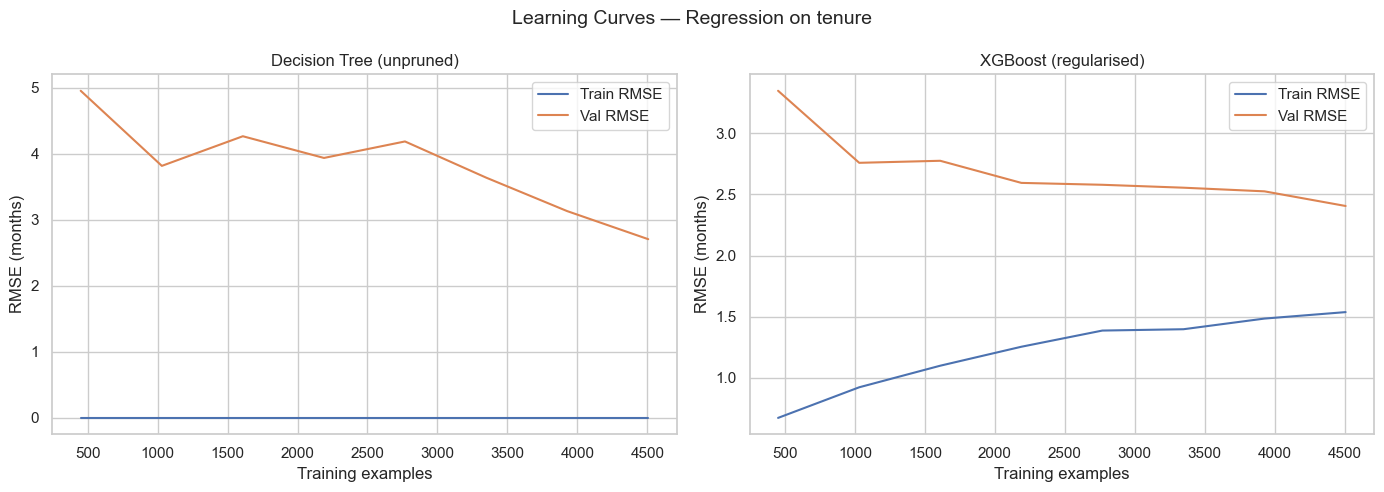

In [22]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
train_sizes_pct = np.linspace(0.1, 1.0, 8)

for ax, (estimator, title) in zip(axes, [
    (DecisionTreeRegressor(max_depth=None, random_state=42),
     'Decision Tree (unpruned)'),
    (XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                  subsample=0.8, colsample_bytree=0.8,
                  reg_alpha=0.1, reg_lambda=1.0, random_state=42),
     'XGBoost (regularised)'),
]):
    # Call learning_curve and unpack into tr_sz, tr_sc, val_sc
    # sklearn returns *negative* RMSE (higher=better convention) — negate when plotting
    tr_sz, tr_sc, val_sc = learning_curve(
        estimator, X_tr_r_enc, y_tr_r,
        train_sizes=train_sizes_pct,
        scoring='neg_root_mean_squared_error',
        cv=5, n_jobs=-1
    )

    ax.plot(tr_sz, -tr_sc.mean(axis=1),  label='Train RMSE')
    ax.plot(tr_sz, -val_sc.mean(axis=1), label='Val RMSE')
    ax.set_title(title)
    ax.set_xlabel('Training examples')
    ax.set_ylabel('RMSE (months)')
    ax.legend()

plt.suptitle('Learning Curves — Regression on tenure', fontsize=14)
plt.tight_layout()
plt.show()


✍️ **Reflect — Q21:** Compare the two plots.
- Which model shows a larger train/val gap at small training sizes?
- As training data grows, which model converges faster?
- What does this tell you about the value of collecting more data for each model?

> **Answer:** The **unpruned Decision Tree** shows a dramatically larger train/val gap at small training sizes — its Train RMSE is essentially 0 (it perfectly memorises every training point) while its Validation RMSE starts high. This is the hallmark of high variance. The **XGBoost model** has a much narrower gap throughout: its Train RMSE is not zero (regularisation prevents perfect fit), and its Validation RMSE starts lower and converges faster. As training data grows, XGBoost converges faster — by ~3,000 samples its validation curve largely stabilises. The unpruned tree's validation curve continues to improve because more data means fewer exact leaf memorisations and better generalisability. For the Decision Tree, collecting more data meaningfully helps — it reduces overfitting by giving the tree more diverse examples. For XGBoost, the model is already well-regularised at 2,000+ samples; collecting more data offers diminishing returns compared to other improvements like better features.


### Q22 — The Extrapolation Failure of Tree Regressors


In [23]:
y_train_max = float(y_tr_r.max())
y_train_min = float(y_tr_r.min())
print(f"Training tenure range: {y_train_min:.0f} \u2013 {y_train_max:.0f} months")

# Predict the full test set with each model
dt_all_preds  = dt_reg.predict(X_te_r_enc)
xgb_all_preds = xgb_reg.predict(X_te_r_enc)

print(f"DT  predictions: {dt_all_preds.min():.1f} \u2013 {dt_all_preds.max():.1f} months")
print(f"XGB predictions: {xgb_all_preds.min():.1f} \u2013 {xgb_all_preds.max():.1f} months")

assert dt_all_preds.max() <= y_train_max + 1e-9, "DT exceeded training max — something is wrong"
print(f"\n\u2705 DT max prediction ({dt_all_preds.max():.1f}) \u2264 y_train_max ({y_train_max:.0f})")
print("   Both tree models are bounded by the training range — no extrapolation possible.")


Training tenure range: 0 – 72 months
DT  predictions: 0.0 – 72.0 months
XGB predictions: -7.7 – 76.7 months

✅ DT max prediction (72.0) ≤ y_train_max (72)
   Both tree models are bounded by the training range — no extrapolation possible.


✍️ **Reflect — Q22:**

**A.** Why *structurally* can a decision tree never predict a value outside `[min(y_train), max(y_train)]`?

**B.** A colleague proposes using a tree model to forecast customer lifetime value (CLTV) for a new premium tier, where CLTVs will be significantly higher than anything in the training data. What would you tell them?

> **Answer A:** A decision tree's prediction mechanism is purely **piecewise constant**: each leaf node stores the **mean of the training samples** that fell into it during training. There is no extrapolation formula — no slope, no gradient, nothing that projects beyond observed values. The maximum a leaf can ever predict is the mean of a set of training targets, which is bounded by `max(y_train)`. Structurally, the tree cannot assign a predicted value to any leaf that exceeds the maximum training target, because leaves are just lookup tables of training means.

> **Answer B:** I would strongly advise against it. A tree model trained on historical CLTV data from standard-tier customers has **never seen the value range of premium-tier CLTVs** — they lie beyond `max(y_train)`. The model would silently cap all premium-tier predictions at the training maximum, making every premium customer appear to have the same high CLTV as the highest historical customer. This removes all discrimination between premium customers and makes the model useless for ranking or budgeting. For extrapolation tasks like this, a **linear model**, **neural network**, or **gradient boosted model with leaf-weight regularisation** would be far more appropriate — these can extrapolate beyond the training range along learned trends.


---
## Completion Checklist

Before submitting, verify that you have:

- [x] **Q1–Q3:** Implemented Gini, Entropy, and Information Gain from scratch — all `SELF-CHECK` cells pass
- [x] **Q4:** Plotted the bias-variance curve and identified the optimal depth
- [x] **Q5:** Fixed the TotalCharges dtype — `SELF-CHECK` cell passes
- [x] **Q6:** Trained the naive tree and identified the accuracy trap
- [x] **Q7:** Computed Precision, Recall, F1 manually from the confusion matrix — `SELF-CHECK` passes
- [x] **Q8:** Implemented `bootstrap_sample()` — `SELF-CHECK` passes
- [x] **Q9:** Trained Bagging and Random Forest and explained the key difference
- [x] **Q10:** Swept XGBoost configurations and explained the gap patterns
- [x] **Q11:** Designed a meaningful Grid Search and identified the most impactful parameter
- [x] **Q12:** Built a `ColumnTransformer` with justified choices
- [x] **Q13:** Reproduced the SMOTE leakage and fixed it with `ImbPipeline`
- [x] **Q14:** Built and fitted the full production pipeline
- [x] **Q15:** Generated a SHAP summary plot and answered the VP's question
- [x] **Q16:** Generated a SHAP waterfall and wrote a 2-sentence retention recommendation
- [x] **Q17:** Serialised, deleted, reloaded, and verified the pipeline
- [x] **Q18:** Completed the Model Card with real numbers from experiments
- [x] **Q19:** Trained a `DecisionTreeRegressor`, computed RMSE/MAE/R², and interpreted the MAE
- [x] **Q20:** Trained a regularised `XGBRegressor` and compared metrics against the baseline
- [x] **Q21:** Plotted learning curves for both models and explained the variance gap
- [x] **Q22:** Demonstrated the extrapolation cap and explained the structural reason

**All ✍️ Reflect cells** have been filled in with specific feature names, real numbers, and business context.

---
*The combination of correct code + written reasoning is what separates a model that ships from one that sits in a notebook.*
